## Andria Linfante
### BINF 5312 Spring 2025
### Term Project - NER
Due 4/22/25

### Install and Import Libraries

In [1]:
%%capture
!pip install datasets
from datasets import Dataset

In [2]:
from spacy.tokens import Doc, Span
import spacy
from spacy import displacy
from transformers import (AutoModelForTokenClassification,
                          AutoTokenizer,
                          pipeline,
                          )

### Import NER Model per code on Hugging Face

In [3]:
model_checkpoint = "jsylee/scibert_scivocab_uncased-finetuned-ner"
model = AutoModelForTokenClassification.from_pretrained(model_checkpoint, num_labels=5,
                                                        id2label={0: 'O', 1: 'B-DRUG', 2: 'I-DRUG', 3: 'B-EFFECT', 4: 'I-EFFECT'}
                                                        )
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

ner_pipeline = pipeline(
    task="ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/885 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/437M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/359 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/228k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/437M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/467k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


### Test Model with Example Review

In [61]:
text = "I was prescribed 50 mg once a day for my anxiety attacks and mild depression. Today is the first day I took it and I hated it! I started off feeling dizzy and intoxicated , then followed sweaty feet and hands while I felt cold all over, I urinated at least 20 times before mid day  as well as constant bowel movements. Dry mouth all day as well. It induced a very strong panic attack which I had to take a xanax for. Muscle twitches along with a rash and extreme restlessness. Loss of appetite which didn't bother me but it felt like I was on speed all day and it made me agitated. Apparently this is just not the right medication for me and to be honest I would rather deal with the few panic attacks I have a week than the side effects of thisRead More Read Less  "

In [5]:
ner_results = ner_pipeline(text)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [6]:
nlp = spacy.blank("en")
doc = nlp(text)

In [7]:
ents = []
for r in ner_results:
    start_char = r['start']
    end_char = r['end']
    label = r['entity_group']
    span = doc.char_span(start_char, end_char, label=label)
    if span:
        ents.append(span)

doc.ents = ents

In [8]:
colors = {"EFFECT": "cyan", "DRUG": "hotpink"}
colour_options = {"ents": ["EFFECT", "DRUG"], "colors": colors}

displacy.render(doc, style="ent", jupyter=True, options=colour_options)

### Load Dataset

In [28]:
import pandas as pd

df = pd.read_csv('psych_drug_webmd_reviews.csv')
df['drug_name_first_word'] = df['drug_name'].str.split().str[0]
print(df.head(2))

   Unnamed: 0        drug_name       date    age  gender  \
0           0  Sertraline Oral  5/12/2024  45-54  Female   
1           1  Sertraline Oral  4/21/2024  35-44  Female   

             time_on_drug reviewer_type                      condition  \
0  1 to less than 2 years       Patient  Posttraumatic Stress Syndrome   
1       less than 1 month       Patient                     Depression   

   rating_overall  rating_effectiveness  rating_ease_of_use  \
0             5.0                     5                   5   
1             1.0                     1                   1   

   rating_satisfaction                                               text  \
0                    5  It's almost two years now and it has been so e...   
1                    1  Iv been on this 4 weeks and iv never felt so a...   

  drug_name_first_word  
0           Sertraline  
1           Sertraline  


### Pre-Processing

In [10]:
df = df.dropna(subset=['text']).copy()

def truncate_text(text, max_tokens=510):
    tokens = tokenizer.tokenize(text)
    if len(tokens) > max_tokens:
        truncated = tokenizer.convert_tokens_to_string(tokens[:max_tokens])
        return truncated
    return text

df['text'] = df['text'].apply(lambda x: truncate_text(str(x)))

In [11]:
hf_dataset = Dataset.from_pandas(df[['text']])

### Run Data through NER Model

In [12]:
ner_results = ner_pipeline(hf_dataset['text'], batch_size=8)

In [13]:
all_entities = []

for idx, entities in enumerate(ner_results):
    for ent in entities:
        all_entities.append({
            "review_index": idx,
            "entity": ent['word'],
            "label": ent['entity_group'],
            "start": ent['start'],
            "end": ent['end']
        })

### Save Output to New Dataframe and Export as CSV

In [29]:
entities_df = pd.DataFrame(all_entities)

entities_df = entities_df.merge(df[['drug_name_first_word']], left_on='review_index', right_index=True)

In [30]:
entities_df.head()

,review_index,entity,label,start,end,drug_name_first_word
0,0,##hin,EFFECT,78,81,Sertraline
1,0,depressed,EFFECT,96,105,Sertraline
2,0,suicidal thoughts,EFFECT,116,133,Sertraline
3,1,angry,EFFECT,45,50,Sertraline
4,1,irritable,EFFECT,52,61,Sertraline


In [31]:
entities_df.to_csv("ner_results.csv", index=False)

In [32]:
from google.colab import files
files.download("ner_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Evaluate Most Common EFFECTs

In [47]:
entities_df['label'].value_counts()

,count
label,
EFFECT,131694
DRUG,57789


In [22]:
entities_df[entities_df['label'] == 'EFFECT']['entity'].value_counts().head(10)

,count
entity,
depression,4331
anxiety,3153
panic attacks,2462
weight gain,2428
nausea,1431
headaches,1390
tired,1229
weight,1199
dizziness,1022


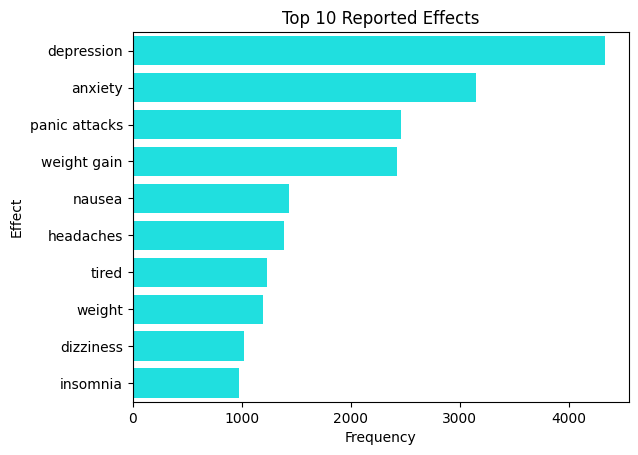

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

top_effects = entities_df[entities_df['label'] == 'EFFECT']['entity'].value_counts().head(10)
sns.barplot(x=top_effects.values, y=top_effects.index, color='cyan')
plt.title("Top 10 Reported Effects")
plt.xlabel("Frequency")
plt.ylabel("Effect")
plt.show()

### Evaluate Most Common EFFECTs by Drug

In [33]:
effects_df = entities_df[entities_df['label'] == 'EFFECT']
top_drugs = effects_df['drug_name_first_word'].value_counts().head(10).index
top_effects = effects_df[effects_df['drug_name_first_word'].isin(top_drugs)]

In [34]:
top_effects_per_drug = (
    top_effects.groupby(['drug_name_first_word', 'entity'])
    .size()
    .reset_index(name='count')
    .sort_values(['drug_name_first_word', 'count'], ascending=[True, False])
    .groupby('drug_name_first_word')
    .head(3)
)

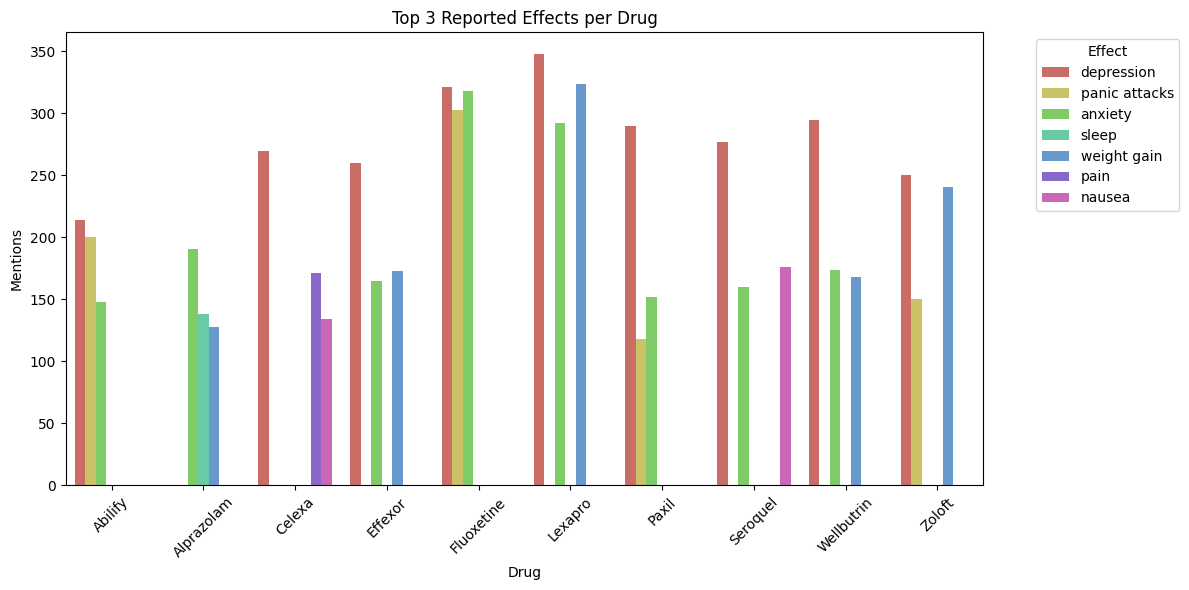

In [46]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_effects_per_drug,
    x='drug_name_first_word',
    y='count',
    hue='entity',
    palette='hls'
)

plt.title('Top 3 Reported Effects per Drug')
plt.xlabel('Drug')
plt.ylabel('Mentions')
plt.xticks(rotation=45)
plt.legend(title='Effect', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Evaluate EFFECT Frequency by Review Count

In [48]:
review_counts = df['drug_name_first_word'].value_counts().reset_index()
review_counts.columns = ['drug_name_first_word', 'num_reviews']

In [49]:
effect_counts = entities_df[entities_df['label'] == 'EFFECT'] \
    .groupby('drug_name_first_word') \
    .size() \
    .reset_index(name='num_effects')

In [50]:
merged_df = pd.merge(review_counts, effect_counts, on='drug_name_first_word')

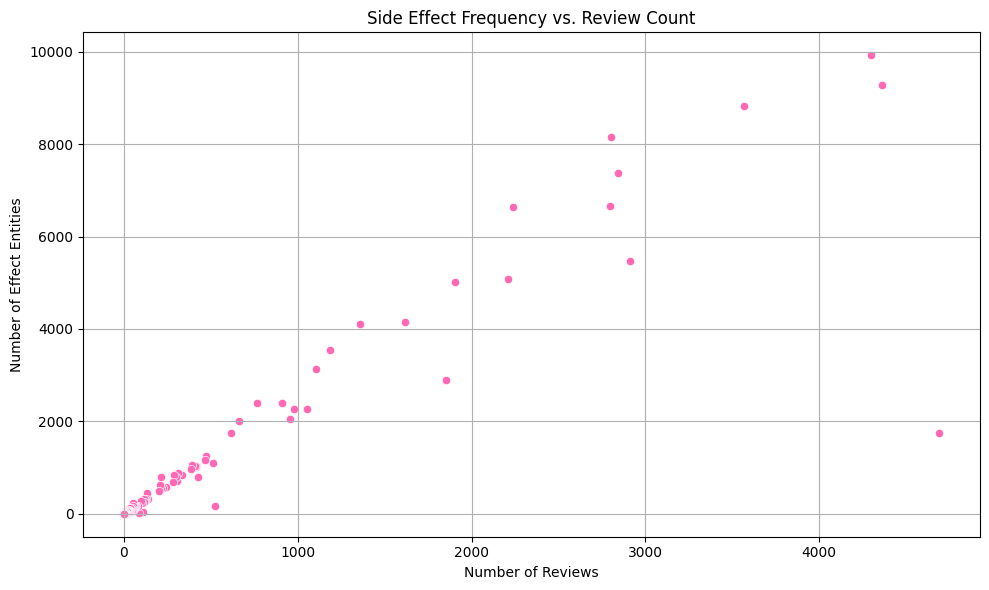

In [62]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x='num_reviews', y='num_effects', color='hotpink')
plt.title('Side Effect Frequency vs. Review Count')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Effect Entities')
plt.grid(True)
plt.tight_layout()
plt.show()

In [58]:
# Locate outlier from plot above
combined = pd.merge(review_counts, effect_counts, on='drug_name_first_word', how='inner')

combined['distance'] = ((combined['num_reviews'] - 4800)**2 + (combined['num_effects'] - 2000)**2)**0.5

outlier_drug = combined.sort_values('distance').head(1)
print(outlier_drug)

  drug_name_first_word  num_reviews  num_effects    distance
0             Cymbalta         4690         1740  282.311884
